In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
# LOAD IMAGE

img = cv2.imread("Radiology_AI_Project/noisy xray image.png")

# Check if image was loaded
if img is None:
    print("Error: Image not found!")


In [ ]:
# Convert BGR (OpenCV default) to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)



# IMAGE INFORMATION

print(f"""Shape: {gray.shape}
Data Type: {gray.dtype}
""")

print(f"""Pixel Sample:
{gray[100:105, 100:105]}
""")

print(f"""Minimum Pixel: {gray.min()}
Maximum Pixel: {gray.max()}
Mean Brightness: {gray.mean()}
Standard Deviation: {gray.std()}""")#MEASURES THE BRIGHTNESS SPREAD:IF IT IS HIGHER, IT MEANS,THERE IS MORE CONTRAST AND VARIATION BUT IF IT IS LOWER, IT MEANS THE IMAGE IS FLATTER AND THERE IS LESS VARIATION.


In [ ]:
#NON-LOCAL MEANS DENOISING
denoised = cv2.fastNlMeansDenoising(
    gray,
    None,
    h=10,
    templateWindowSize=7,
    searchWindowSize=21,

                                    )

# IMAGE FILTERING

# Mean Filter (Averaging)
mean_filter = cv2.blur(denoised,
                       (5, 5)
                       )

# Gaussian Filter
gaussian_filter = cv2.GaussianBlur(denoised,
                                   (5, 5),
                                   0
                                   )

# Median Filter
median_filter = cv2.medianBlur(denoised,
                               5
                               )

In [ ]:
#CLAHE:IMPROVES LOCAL CONTRAST

clahe = cv2.createCLAHE(clipLimit=2.0,
                        tileGridSize=(8,8)
                        )
clahe_img = clahe.apply(denoised
                        )

#GAMMA CORRECTION:ADJUSTS OVERALL BRIGHTNESS BEHAVIOR
gamma = 1.3

lookup = np.array([
    ((i/255.0) ** (1/gamma)) *  255
    for i in range(256)
]).astype("uint8")

gamma_corrected = cv2.LUT(
    clahe_img,
    lookup
)


#UNSHARP MASKING
blurred = cv2.GaussianBlur(
    gamma_corrected,
    (9,9),
    10
)

unsharp = cv2.addWeighted(
    gamma_corrected,
    1.5,
    blurred,
    -0.5,
    0
)


# Sharpening Filter(kernel):MAKES EDGES STRONGER
sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharpened = cv2.filter2D(
    unsharp,
    -1,
    sharpen_kernel
)

# Histogram Equalization
#equalized = cv2.equalizeHist(gray)
#ADAPTIVE THRESHOLD:THIS IS CHECKING THAT FOR EACH PIXEL, LOOK AT SURROUNDING 11*11 REGION,COMPUTE LOCAL AVERAGE(GAUSSIAN WEIGHTED),SUBTRACT 2,COMPARE PIXEL TO THAT VALUE,DECIDE BLACK OR WHITE.THIS HELPS HIGHLIGHT DENSE AREAS,SEPARATE STRUCTURES,AND SUPPRESS BACKGROUND.I.E DECIDES WHAT IS STRUCTURE VS WHAT IS BACKGROUND LOCALLY.
adaptive = cv2.adaptiveThreshold(
    sharpened,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)


# Histogram Equalization
equalized = cv2.equalizeHist(gray)


# Edge Detection
edges = cv2.Canny(sharpened,
                  100,
                  200
                  )







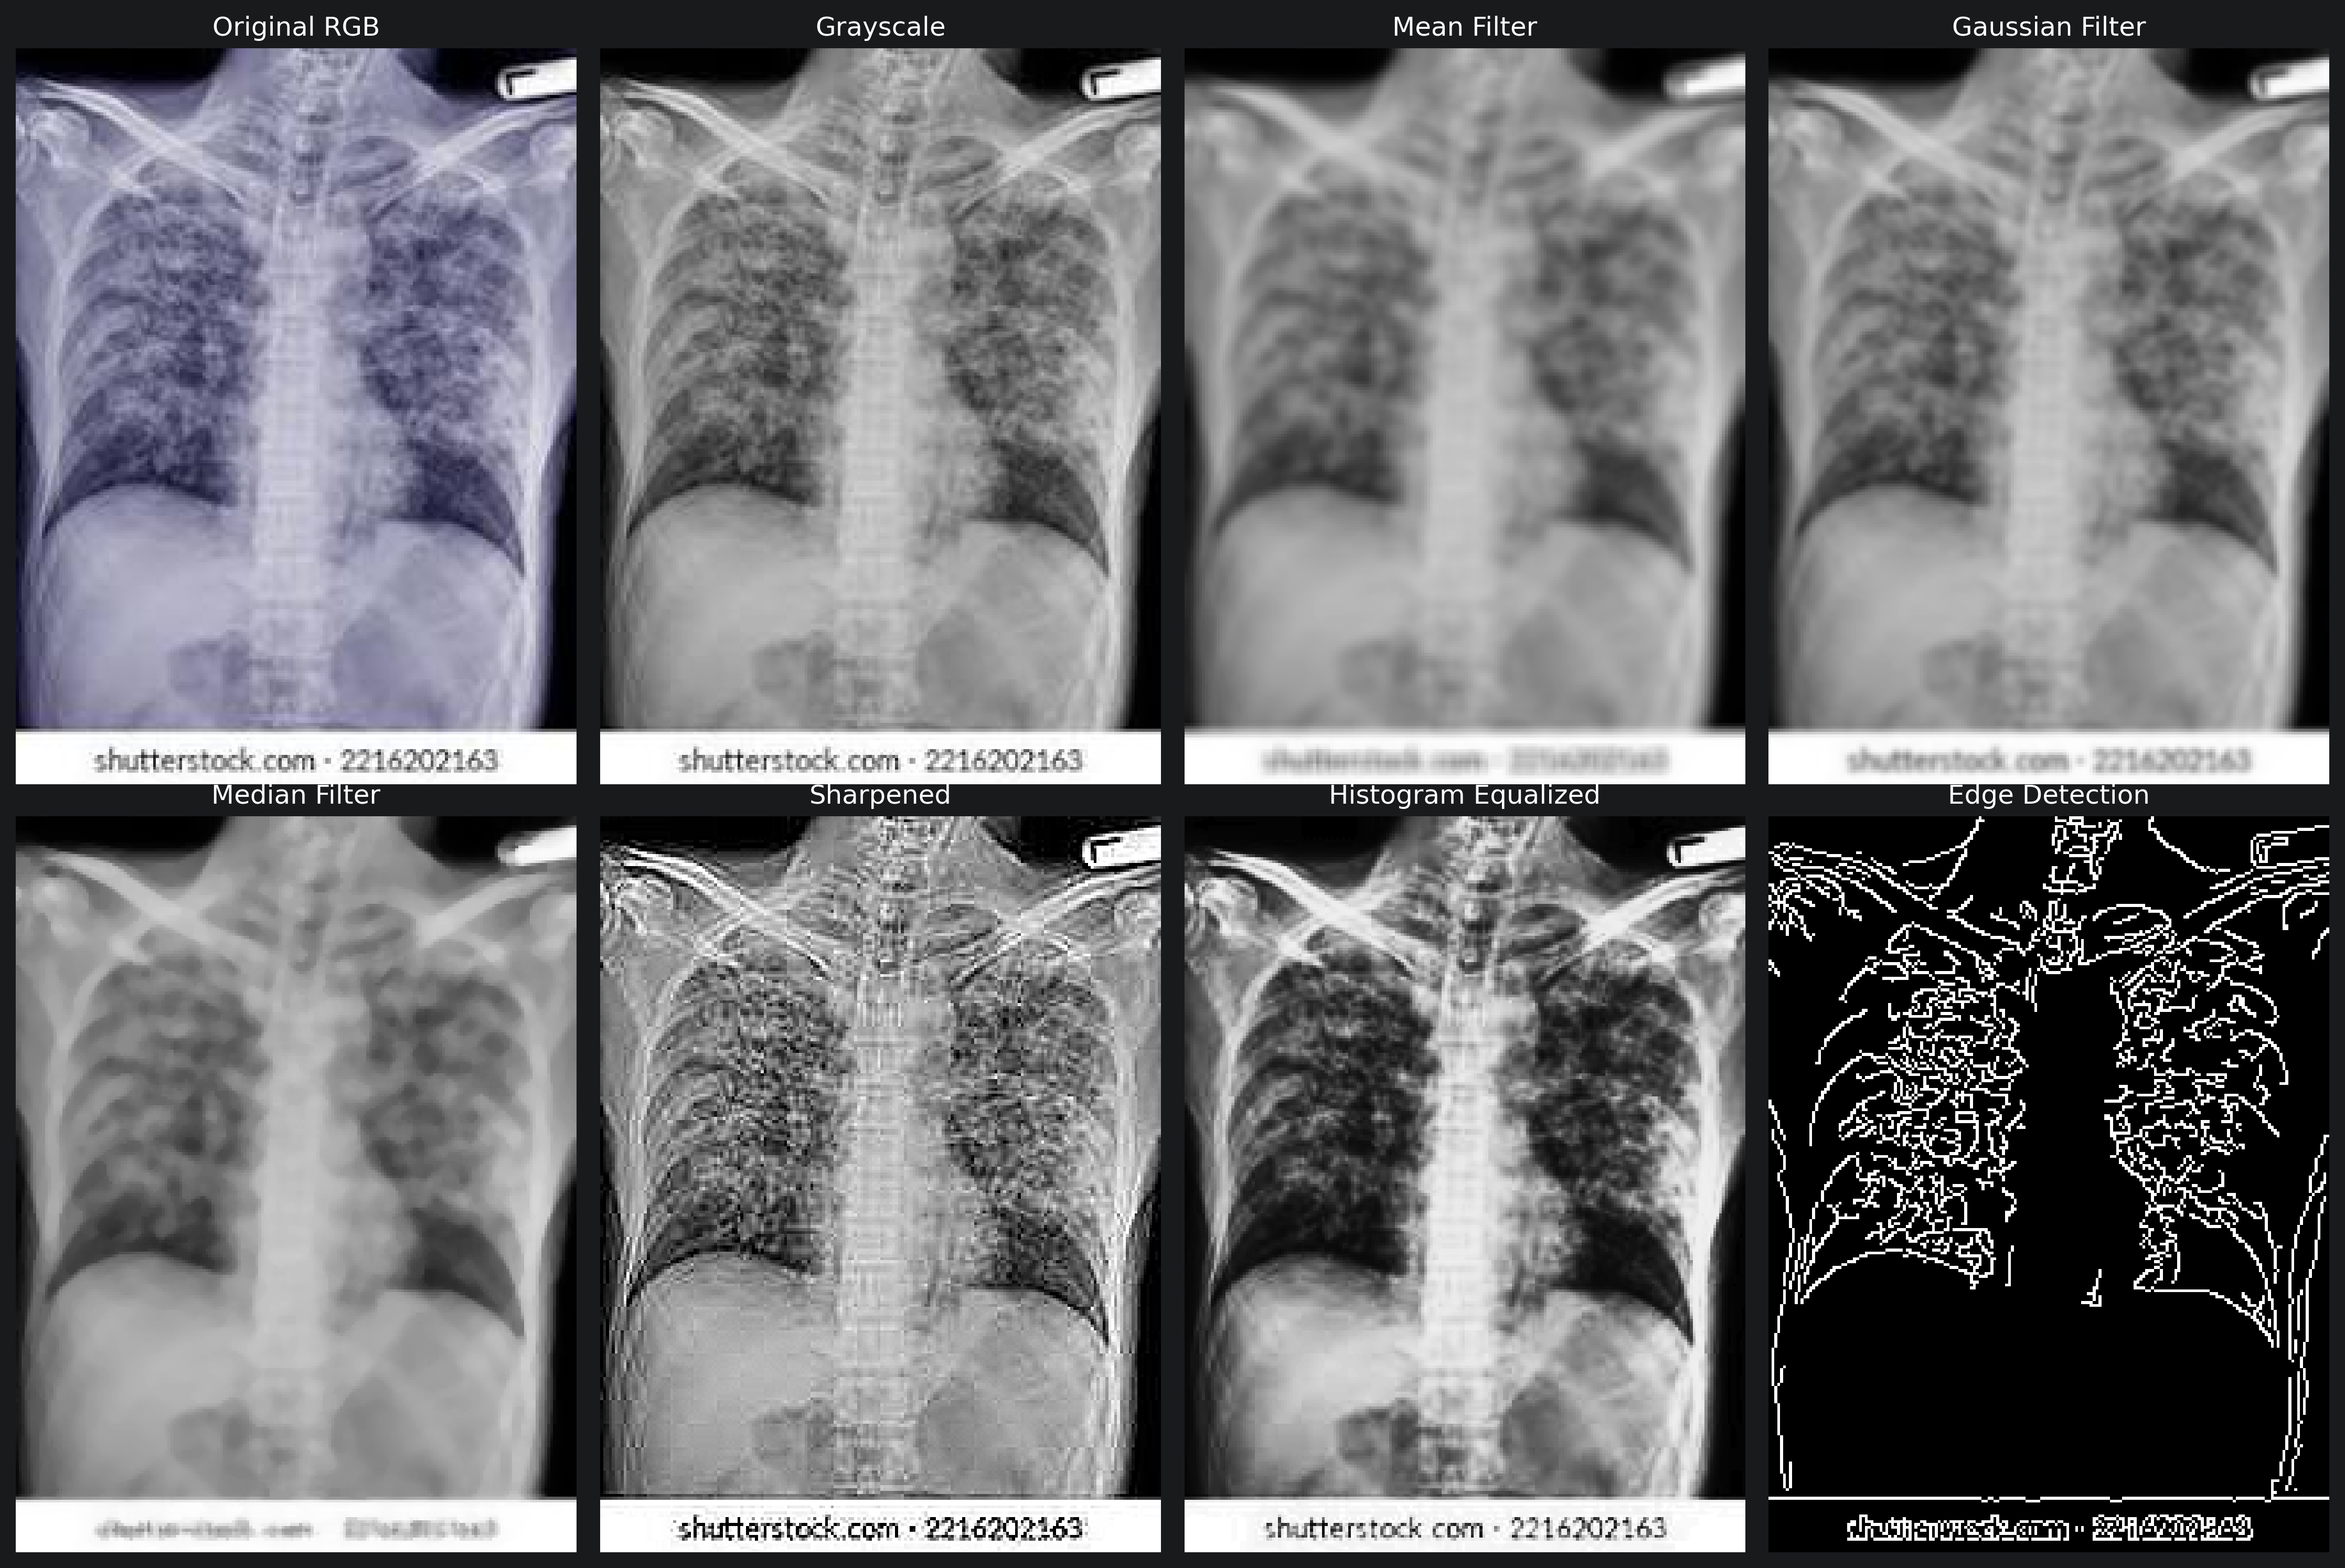


Enhanced image saved as 'enhanced x_ray.jpg


In [4]:
# DISPLAY RESULTS

titles = [
    "Original RGB",
    "Grayscale",
    "Mean Filter",
    "Gaussian Filter",
    "Median Filter",
    "Sharpened",
    "Histogram Equalized",
    "Edge Detection"
]

images = [
    img_rgb,
    gray,
    mean_filter,
    gaussian_filter,
    median_filter,
    sharpened,
    equalized,
    edges
]

plt.figure(figsize=(15, 10), dpi=300)

for i in range(len(images)):
    plt.subplot(2, 4, i + 1)

    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap="gray")
    else:
        plt.imshow(images[i])

    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()



# SAVE OUTPUT IMAGE

cv2.imwrite("outputs/enhanced_xray.jpg", equalized)

print("\nEnhanced image saved as 'enhanced x_ray.jpg")


    Image loaded successfully!
    Image shape: (1317, 1857, 3),uint8
    
Pixel Sample:
    [[[25 25 25]
  [25 25 25]
  [25 25 25]
  [25 25 25]
  [24 24 24]]

 [[25 25 25]
  [25 25 25]
  [25 25 25]
  [25 25 25]
  [24 24 24]]

 [[24 24 24]
  [24 24 24]
  [24 24 24]
  [24 24 24]
  [24 24 24]]

 [[23 23 23]
  [23 23 23]
  [23 23 23]
  [23 23 23]
  [24 24 24]]

 [[23 23 23]
  [21 21 21]
  [22 22 22]
  [24 24 24]
  [23 23 23]]]
    


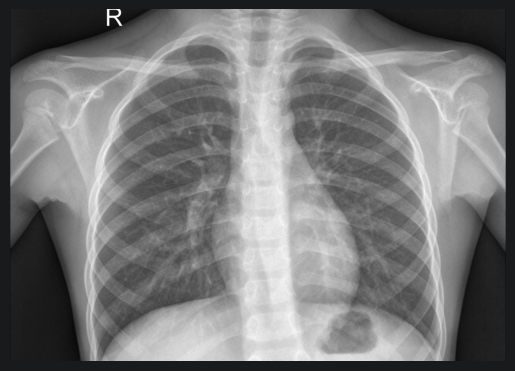

True


In [1]:
#IMAGE LOADING AND INSPECTION
import cv2
import numpy as np
import matplotlib.pyplot as plt


# ==========================
# LOAD IMAGE
# ==========================
img = cv2.imread("../../Radiology_AI_Project/chest_xray.jpg")
if img is None:
    print("Error: Image not found!")
else:
    print(f'''
    Image loaded successfully!
    Image shape: {img.shape},{img.dtype}
    '''
          )
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)


    plt.axis('off')

    print(f"""Pixel Sample:
    {img_rgb[100:105, 100:105]}
    """)
    plt.show()
    b,g,r = cv2.split(img)
    print(np.array_equal(b,g) and np.array_equal(g,r))


Shape: (252, 192)
Data Type: uint8

Pixel Sample:
[[197 196 191 186 184]
 [194 195 191 186 186]
 [191 193 190 187 186]
 [189 192 191 188 189]
 [196 198 193 187 182]]



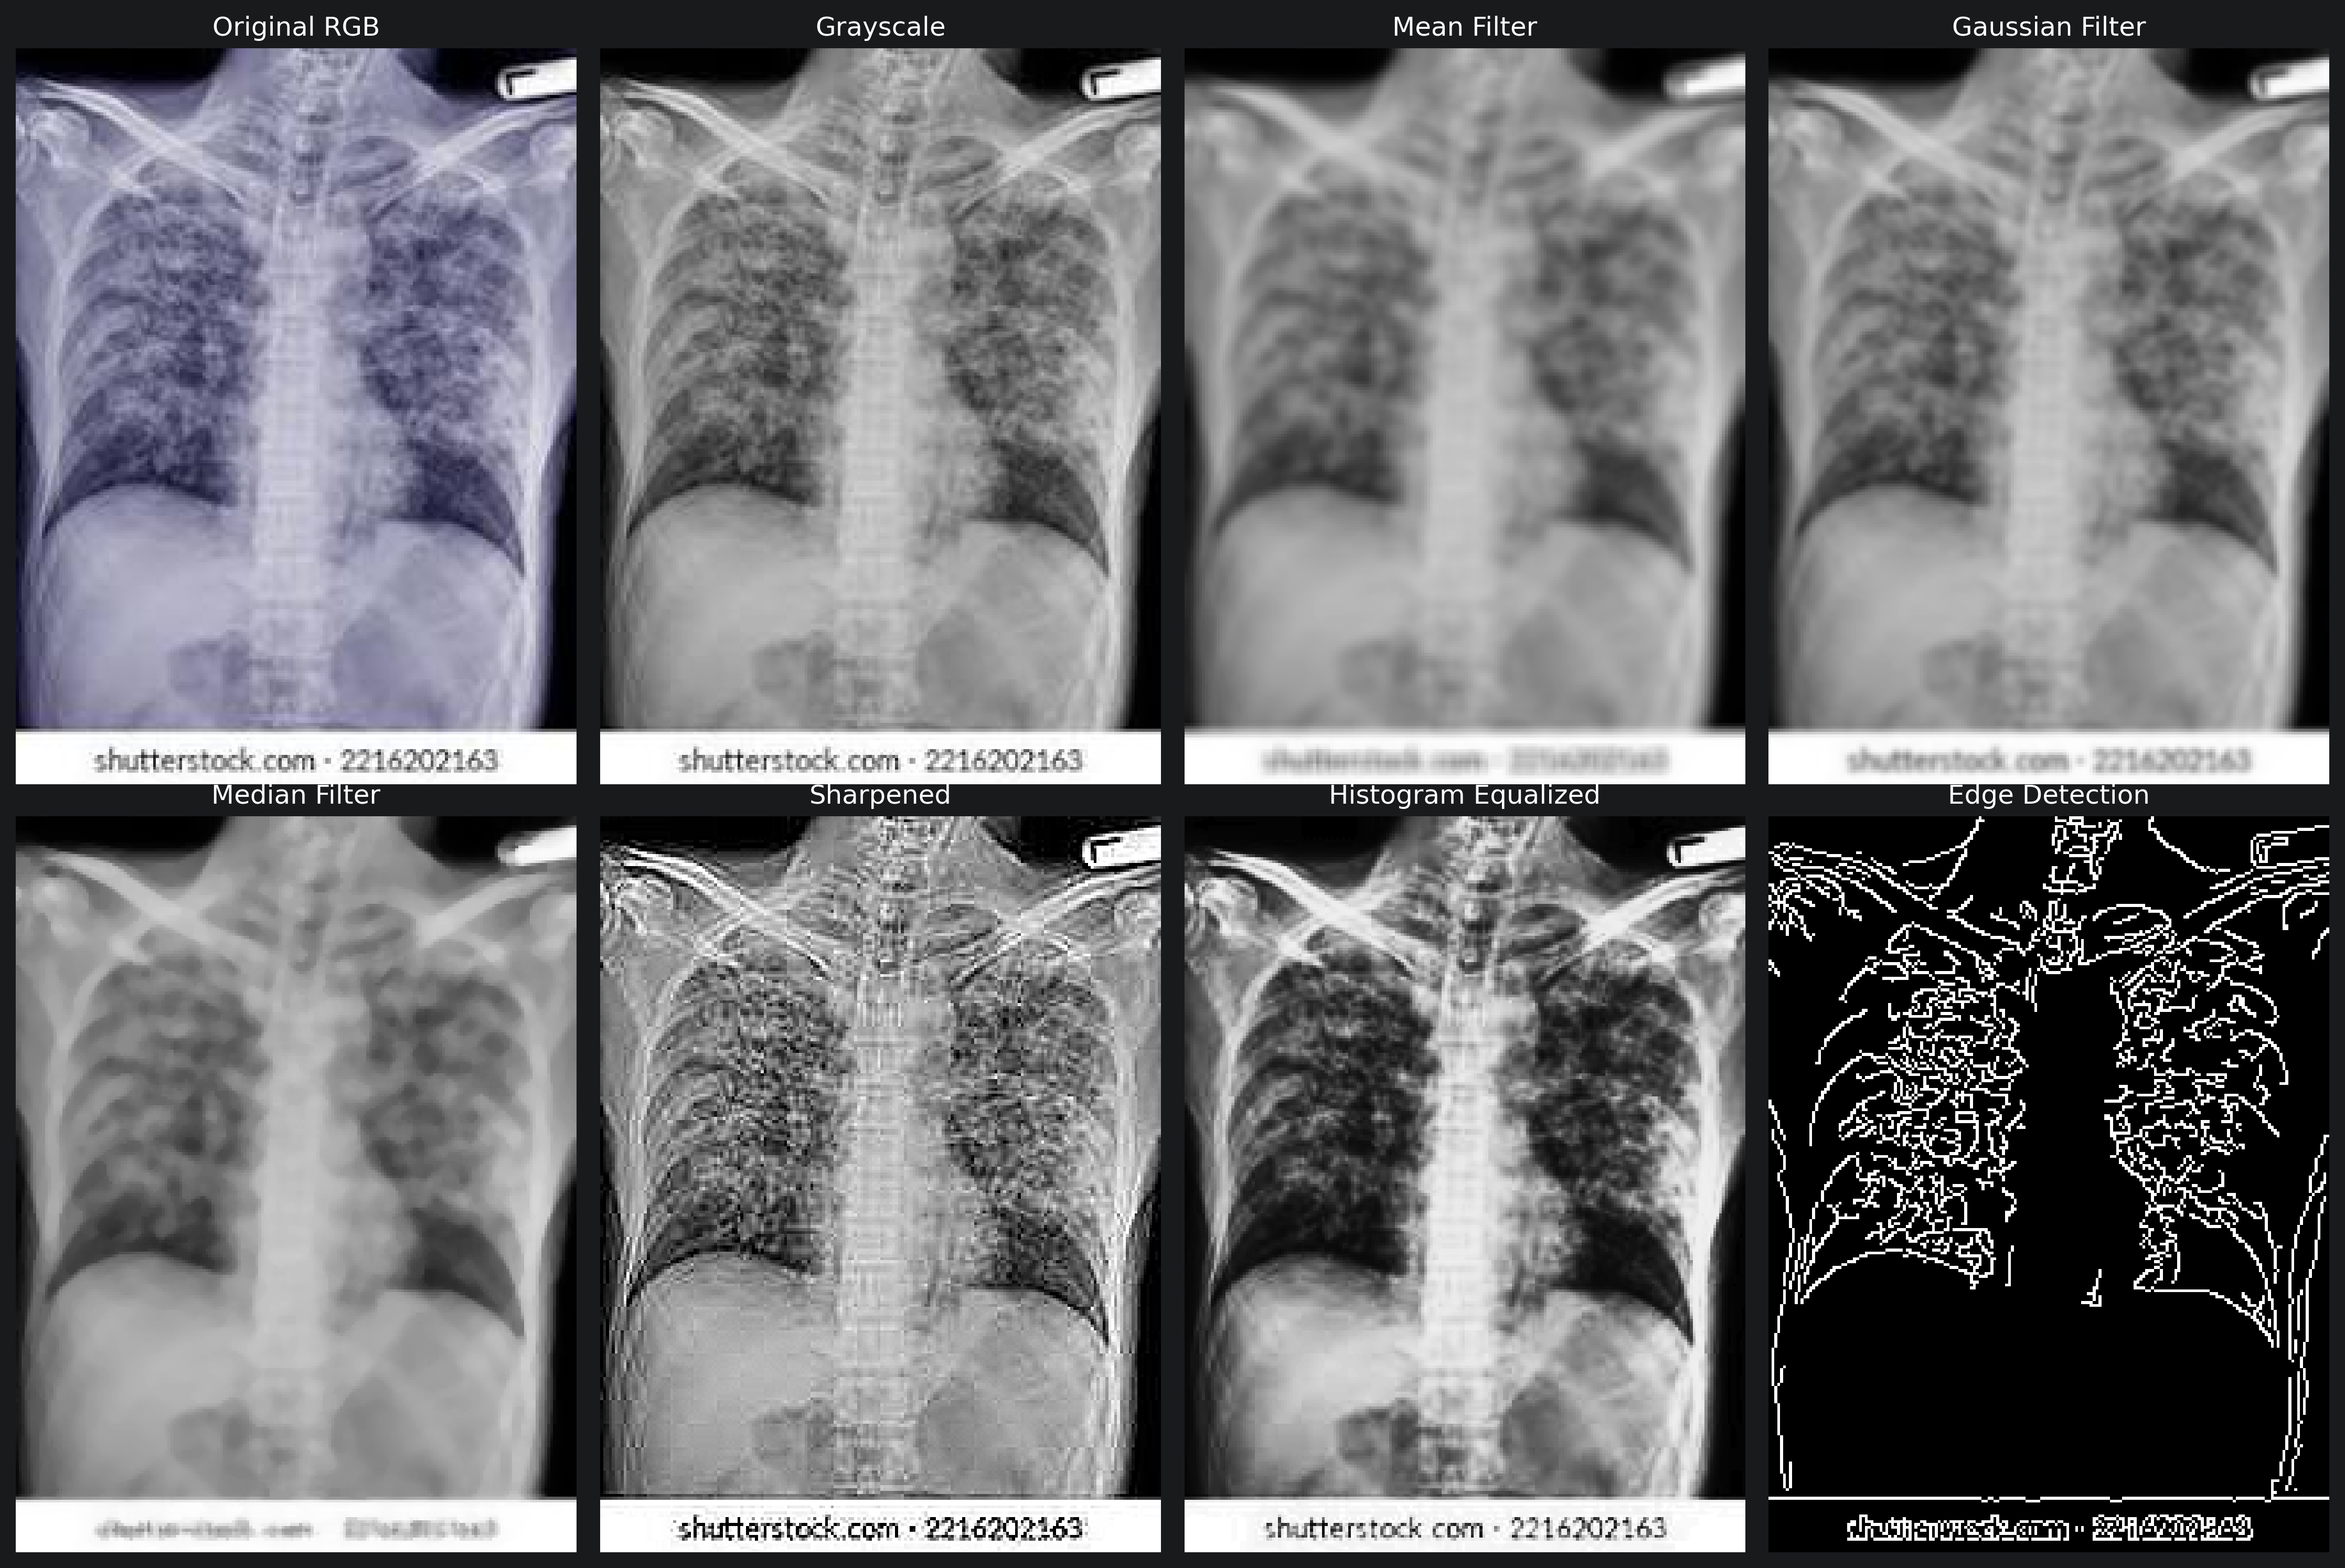


Enhanced image saved as 'enhanced x_ray.jpg


In [5]:
#FILTER COMPARISONS EXPERIMENTS
import cv2
import numpy as np
import matplotlib.pyplot as plt



# LOAD IMAGE

img = cv2.imread("../../Radiology_AI_Project/noisy xray image.png")

# Check if image was loaded
if img is None:
    print("Error: Image not found!")
    exit()

# Convert BGR (OpenCV default) to RGB for display
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)



# IMAGE INFORMATION

print(f"""Shape: {gray.shape}
Data Type: {gray.dtype}
""")

print(f"""Pixel Sample:
{gray[100:105, 100:105]}
""")



# IMAGE FILTERING

# Mean Filter (Averaging)
mean_filter = cv2.blur(gray, (5, 5))

# Gaussian Filter
gaussian_filter = cv2.GaussianBlur(gray, (5, 5), 0)

# Median Filter
median_filter = cv2.medianBlur(gray, 5)

# Sharpening Filter
sharpen_kernel = np.array([
    [0, -1, 0],
    [-1, 5, -1],
    [0, -1, 0]
])

sharpened = cv2.filter2D(gray, -1, sharpen_kernel)

# Histogram Equalization
equalized = cv2.equalizeHist(gray)

# Edge Detection
edges = cv2.Canny(gray, 100, 200)



# DISPLAY RESULTS

titles = [
    "Original RGB",
    "Grayscale",
    "Mean Filter",
    "Gaussian Filter",
    "Median Filter",
    "Sharpened",
    "Histogram Equalized",
    "Edge Detection"
]

images = [
    img_rgb,
    gray,
    mean_filter,
    gaussian_filter,
    median_filter,
    sharpened,
    equalized,
    edges
]

plt.figure(figsize=(15, 10), dpi=300)

for i in range(len(images)):
    plt.subplot(2, 4, i + 1)

    if len(images[i].shape) == 2:
        plt.imshow(images[i], cmap="gray")
    else:
        plt.imshow(images[i])

    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()



# SAVE OUTPUT IMAGE

cv2.imwrite("outputs/enhanced_xray.jpg", equalized)

print("\nEnhanced image saved as 'enhanced x_ray.jpg")